# Exercises XP Ninja: Advanced CNN Projects

This guided notebook follows the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts to support intuition or transfer to other AI topics.


## What you will learn
- Advanced CNN architectures and techniques
- Handling imbalanced datasets
- Transfer learning and fine tuning
- Model interpretability and visualization
- Building a robust classification pipeline


## What you will create
Five CNN based projects. Each addresses a specific challenge.


## Common setup

**As stated in the exercises**  
You will build and evaluate CNN models under different constraints.

**PREFILLED**  
Imports, versions, seed control, and a simple plot helper. Execute this first.


In [1]:
# PREFILLED: just execute
import os, time, math, json, random, itertools
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow:", tf.__version__)

def plot_history(history, title="Training curves"):
    plt.figure(figsize=(6,4))
    if "accuracy" in history.history: plt.plot(history.history["accuracy"], label="acc")
    if "val_accuracy" in history.history: plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    if "loss" in history.history: plt.plot(history.history["loss"], label="loss")
    if "val_loss" in history.history: plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

TensorFlow: 2.19.0


# Exercise 1: Multi label image classification

**As stated in the exercises**  
Choose a dataset where each image can have multiple labels. Build a CNN with a sigmoid output and use binary cross entropy. Handle dependencies between labels by experimenting with approaches such as recurrent layers or label embeddings.


### 1.1 Dataset interface

**PREFILLED**  
Expected CSV format: `filepath,labels` where `labels` is a `|` separated list. The code below parses the CSV and builds a multi hot vector per image based on the discovered vocabulary. If no CSV is provided, a toy multi label dataset is synthesized from CIFAR 10 using attributes such as `animal` and `vehicle` for demonstration.


In [2]:
# PREFILLED: just execute
import pandas as pd

def build_multilabel_from_csv(csv_path, root_dir):
    df = pd.read_csv(csv_path)
    df['filepath'] = df['filepath'].astype(str)
    df['labels'] = df['labels'].astype(str)
    vocab = sorted(set(itertools.chain.from_iterable([s.split('|') for s in df['labels']])))
    tok = {t:i for i,t in enumerate(vocab)}
    y = np.zeros((len(df), len(vocab)), dtype=np.float32)
    for i, s in enumerate(df['labels']):
        for t in s.split('|'):
            y[i, tok[t]] = 1.0
    x_paths = [str(Path(root_dir)/p) for p in df['filepath']]
    return x_paths, y, vocab

def load_image(path, size=(160,160)):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, size)
    return img

def make_dataset_multilabel(x_paths, y, batch=32, shuffle=True, aug=False, size=(160,160)):
    x = tf.constant(x_paths)
    y = tf.constant(y, dtype=tf.float32)
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    def _map(p, lab):
        im = load_image(p, size)
        if aug:
            im = tf.image.random_flip_left_right(im)
            im = tf.image.random_brightness(im, 0.1)
            im = tf.image.random_contrast(im, 0.9, 1.1)
        return im, lab
    if shuffle:
        ds = ds.shuffle(buffer_size=min(10000, len(x_paths)))
    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE).batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

# Try to locate a CSV next to this notebook
CSV_CANDIDATES = [p for p in Path('.').glob('*.csv')]
if CSV_CANDIDATES:
    print("Found CSV:", CSV_CANDIDATES[0])
else:
    print("No CSV found. A toy dataset will be used if you run the fallback cell below.")

No CSV found. A toy dataset will be used if you run the fallback cell below.


In [3]:
# PREFILLED: just execute: toy multi label fallback using CIFAR 10
from tensorflow.keras.datasets import cifar10
(x_tr_c10, y_tr_c10), (x_te_c10, y_te_c10) = cifar10.load_data()
y_tr_c10 = y_tr_c10.ravel(); y_te_c10 = y_te_c10.ravel()
# attributes: animal vs vehicle, pet vs wild
attr = {
    0: ("vehicle","air"),     # airplane
    1: ("vehicle","land"),    # automobile
    2: ("animal","wild"),     # bird
    3: ("animal","pet"),      # cat
    4: ("animal","wild"),     # deer
    5: ("animal","pet"),      # dog
    6: ("animal","wild"),     # frog
    7: ("animal","pet"),      # horse as non pet but domesticated
    8: ("vehicle","water"),   # ship
    9: ("vehicle","land"),    # truck
}
vocab = sorted(list(set(itertools.chain.from_iterable(attr.values()))))
tok = {t:i for i,t in enumerate(vocab)}

def to_multi_hot(y):
    out = np.zeros((len(y), len(vocab)), dtype=np.float32)
    for i,c in enumerate(y):
        a,b = attr[int(c)]
        out[i, tok[a]] = 1.0
        out[i, tok[b]] = 1.0
    return out

y_tr_ml = to_multi_hot(y_tr_c10)
y_te_ml = to_multi_hot(y_te_c10)

def ds_from_numpy(x, y, size=(160,160), batch=64, aug=False):
    x = tf.convert_to_tensor(x)
    y = tf.convert_to_tensor(y, dtype=tf.float32)
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    def _map(im, lab):
        im = tf.image.convert_image_dtype(im, tf.float32)
        im = tf.image.resize(im, size)
        if aug:
            im = tf.image.random_flip_left_right(im)
            im = tf.image.random_brightness(im, 0.1)
        return im, lab
    return ds.shuffle(5000).map(_map, num_parallel_calls=tf.data.AUTOTUNE).batch(batch).prefetch(tf.data.AUTOTUNE)

train_ds_ml = ds_from_numpy(x_tr_c10, y_tr_ml, aug=True)
val_ds_ml   = ds_from_numpy(x_te_c10, y_te_ml, aug=False)
print("Toy multi label dataset ready. Labels:", vocab)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Toy multi label dataset ready. Labels: ['air', 'animal', 'land', 'pet', 'vehicle', 'water', 'wild']


### 1.2 Build a multi label CNN

**To-Do:** Create a CNN that outputs `len(vocab)` logits with sigmoid activation. Compile with `binary_crossentropy`. Train on your dataset and report micro and macro F1 on the validation set. Save the list of labels you used.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,615 (111.78 KB)

 Trainable params: 28,615 (111.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 - 65s - 104ms/step - accuracy: 0.5949 - loss: 0.4257 - val_accuracy: 0.5781 - val_loss: 0.3642
Epoch 2/10
625/625 - 73s - 117ms/step - accuracy: 0.6203 - loss: 0.3462 - val_accuracy: 0.6140 - val_loss: 0.3232
Epoch 3/10
625/625 - 81s - 130ms/step - accuracy: 0.6306 - loss: 0.3213 - val_accuracy: 0.6410 - val_loss: 0.3088
Epoch 4/10
625/625 - 52s - 84ms/step - accuracy: 0.6356 - loss: 0.3076 - val_accuracy: 0.6421 - val_loss: 0.2981
Epoch 5/10
625/625 - 52s - 83ms/step - accuracy: 0.6399 - loss: 0.2965 - val_accuracy: 0.6414 - val_loss: 0.2877
Epoch 6/10
625/625 - 83s - 133ms/step - accuracy: 0.6446 - loss: 0.2870 - val_accuracy: 0.6442 - val_loss: 0.2796
Epoch 7/10
625/625 - 52s - 83ms/step - accuracy: 0.6494 - loss: 0.2794 - val_accuracy: 0.6423 - val_loss: 0.2726
Epoch 8/10
625/625 - 81s - 130ms/step - accuracy: 0.6533 - loss: 0.2726 - val_accuracy: 0.6452 - val_loss: 0.2660
Epoch 9/10
625/625 - 51s - 82ms/step - accuracy: 0.6581 - loss: 0.2665 - val_accuracy: 0.64

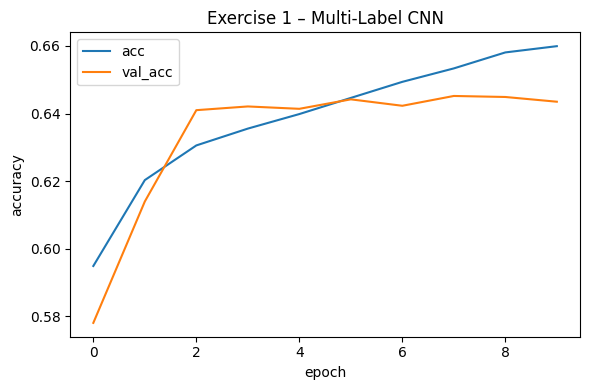

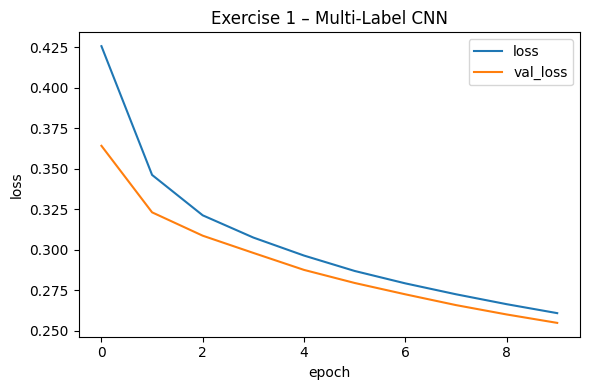

In [4]:
# To-Do: define and train the multi label model
inputs = layers.Input(shape=(32,32,3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64,(3,3),activation='relu',padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128,activation='relu')(x)
outputs = layers.Dense(len(vocab),activation='sigmoid')(x)

model_ml = models.Model(inputs, outputs)
model_ml.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_ml.summary()

h_ml = model_ml.fit(x_tr_c10, y_tr_ml, epochs=10, batch_size=64,
                    validation_split=0.2, verbose=2)
plot_history(h_ml, title="Exercise 1 – Multi-Label CNN")


In [5]:
# To-Do: compute micro and macro F1
from sklearn.metrics import f1_score

y_pred = model_ml.predict(x_te_c10) > 0.5
f1_micro = f1_score(y_te_ml, y_pred, average="micro")
f1_macro = f1_score(y_te_ml, y_pred, average="macro")
print(f"✅ F1 micro: {f1_micro:.3f} | F1 macro: {f1_macro:.3f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step
✅ F1 micro: 0.803 | F1 macro: 0.719


### 1.3 Capture label dependencies

**To-Do:** Add a simple label dependency module. Example options: a Dense layer on logits to allow interaction, a small GRU over label dimension, or a learned label embedding with self attention. Train and compare F1 to the base model.


**Learning point**  
Multi label outputs model independent Bernoulli decisions. Explicitly modeling co occurrence can improve calibration and reduce contradictory predictions.


# Exercise 2: Class imbalance handling

**As stated in the exercises**  
Select a dataset with strong class imbalance. Train a CNN and address imbalance with oversampling, undersampling, or weighted loss. Evaluate with precision, recall, F1, and AUC ROC and compare to a baseline.


### 2.1 Simulate imbalance

**PREFILLED**  
We create an imbalanced subset of CIFAR 10 by downsampling one class.


In [6]:
# PREFILLED: just execute
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = y_train.ravel(); y_test = y_test.ravel()

minor_class = 2  # bird
keep_minor = 300
keep_major = 5000

idx_minor = np.where(y_train==minor_class)[0]
idx_major = np.where(y_train!=minor_class)[0]
sel = np.concatenate([np.random.choice(idx_minor, keep_minor, replace=False),
                      np.random.choice(idx_major, keep_major, replace=False)])
np.random.shuffle(sel)
x_imb = x_train[sel]; y_imb = y_train[sel]
print("Imbalanced set:", x_imb.shape, "minority ratio:", (y_imb==minor_class).mean())

Imbalanced set: (5300, 32, 32, 3) minority ratio: 0.05660377358490566


### 2.2 Baseline model and metrics

**To-Do:** Train a baseline CNN on the imbalanced set without any correction. Compute precision, recall, F1 per class and macro average. Plot a normalized confusion matrix.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
34/34 - 13s - 377ms/step - accuracy: 0.1472 - loss: 2.2657 - val_accuracy: 0.1604 - val_loss: 2.2108
Epoch 2/10
34/34 - 5s - 147ms/step - accuracy: 0.2085 - loss: 2.1491 - val_accuracy: 0.2217 - val_loss: 2.1105
Epoch 3/10
34/34 - 6s - 185ms/step - accuracy: 0.2307 - loss: 2.0685 - val_accuracy: 0.2472 - val_loss: 2.0663
Epoch 4/10
34/34 - 10s - 297ms/step - accuracy: 0.2500 - loss: 2.0356 - val_accuracy: 0.2472 - val_loss: 2.0484
Epoch 5/10
34/34 - 9s - 267ms/step - accuracy: 0.2587 - loss: 2.0126 - val_accuracy: 0.2491 - val_loss: 2.0294
Epoch 6/10
34/34 - 6s - 186ms/step - accuracy: 0.2781 - loss: 1.9906 - val_accuracy: 0.2783 - val_loss: 2.0113
Epoch 7/10
34/34 - 5s - 157ms/step - accuracy: 0.2795 - loss: 1.9684 - val_accuracy: 0.2745 - val_loss: 1.9954
Epoch 8/10
34/34 - 8s - 221ms/step - accuracy: 0.2899 - loss: 1.9482 - val_accuracy: 0.2896 - val_loss: 1.9778
Epoch 9/10
34/34 - 5s - 155ms/step - accuracy: 0.2955 - loss: 1.9265 - val_accuracy: 0.2858 - val_loss: 1.9623

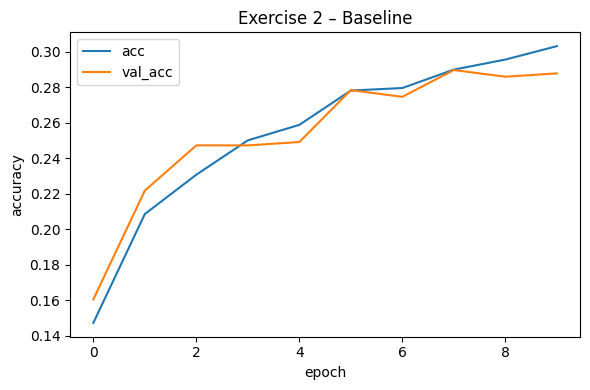

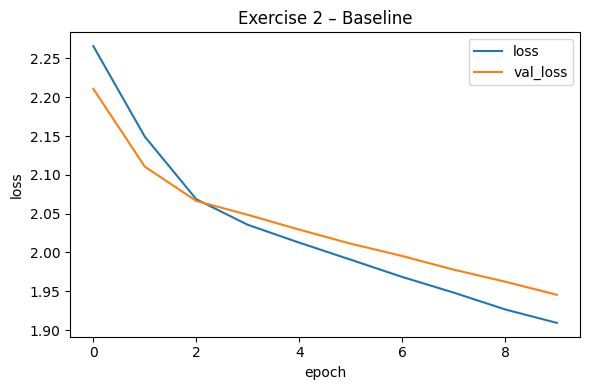

In [7]:
# To-Do: train baseline on x_imb, y_imb
base = tf.keras.Sequential([
    layers.Rescaling(1./255, input_shape=(32,32,3)),
    layers.Conv2D(32,3,activation='relu',padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,activation='relu',padding='same'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(10,activation='softmax')
])
base.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h_base = base.fit(x_imb, y_imb, epochs=10, batch_size=128,
                  validation_split=0.2, verbose=2)
plot_history(h_base, title="Exercise 2 – Baseline")


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step
📊 Classification Report:
              precision    recall  f1-score   support

           0      0.454     0.128     0.200      1000
           1      0.239     0.686     0.355      1000
           2      0.000     0.000     0.000      1000
           3      0.193     0.098     0.130      1000
           4      0.335     0.272     0.300      1000
           5      0.257     0.225     0.240      1000
           6      0.310     0.481     0.377      1000
           7      0.288     0.080     0.125      1000
           8      0.263     0.726     0.386      1000
           9      0.197     0.013     0.024      1000

    accuracy                          0.271     10000
   macro avg      0.254     0.271     0.214     10000
weighted avg      0.254     0.271     0.214     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


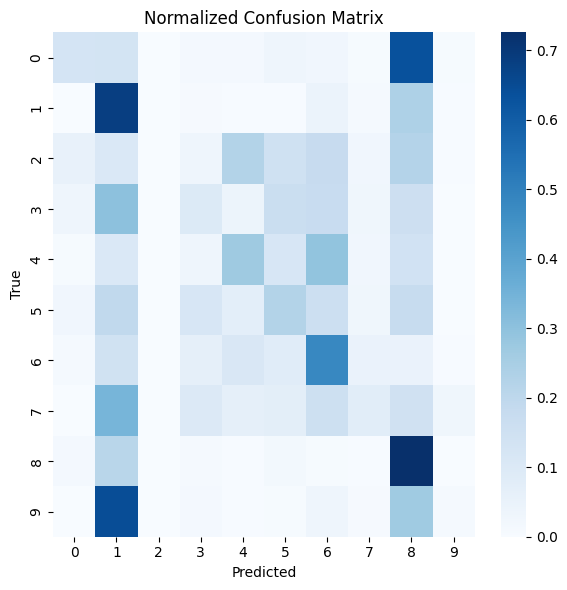

In [8]:
# To-Do: evaluate baseline with precision, recall, F1, and confusion matrix
# ✅ 2.2 Evaluate baseline with precision, recall, F1, and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Generate predictions
y_pred = base.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

# Print classification metrics
print("📊 Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

# Compute and visualize confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=list(range(10)))
plt.figure(figsize=(6,6))
sns.heatmap(cm / cm.sum(axis=1, keepdims=True), annot=False, cmap="Blues")
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


### 2.3 Apply imbalance techniques

**To-Do:** Train three new runs using: class weights, oversampling, and focal loss. Keep the architecture fixed. Compare the per class recall and macro F1.


Class weights: {np.uint8(0): np.float64(1.0577617328519855), np.uint8(1): np.float64(1.0932835820895523), np.uint8(2): np.float64(1.9533333333333334), np.uint8(3): np.float64(1.1290944123314066), np.uint8(4): np.float64(1.0316901408450705), np.uint8(5): np.float64(1.0), np.uint8(6): np.float64(1.099437148217636), np.uint8(7): np.float64(1.0209059233449478), np.uint8(8): np.float64(1.0280701754385966), np.uint8(9): np.float64(1.0464285714285715)}
Epoch 1/10
34/34 - 11s - 312ms/step - accuracy: 0.1267 - loss: 2.5261 - val_accuracy: 0.1594 - val_loss: 2.2349
Epoch 2/10
34/34 - 9s - 261ms/step - accuracy: 0.1884 - loss: 2.4151 - val_accuracy: 0.1840 - val_loss: 2.1503
Epoch 3/10
34/34 - 11s - 315ms/step - accuracy: 0.2090 - loss: 2.3221 - val_accuracy: 0.2142 - val_loss: 2.0769
Epoch 4/10
34/34 - 5s - 149ms/step - accuracy: 0.2262 - loss: 2.2774 - val_accuracy: 0.2321 - val_loss: 2.0425
Epoch 5/10
34/34 - 6s - 183ms/step - accuracy: 0.2311 - loss: 2.2492 - val_accuracy: 0.2547 - val_loss: 

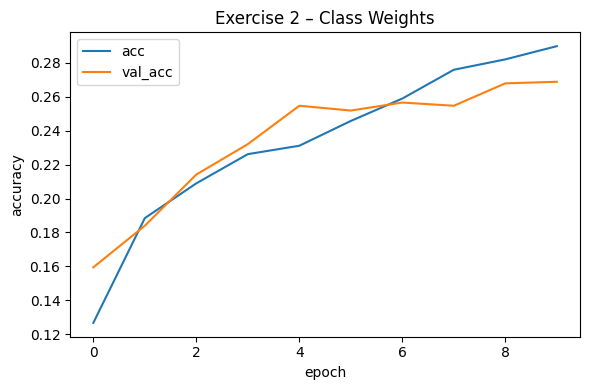

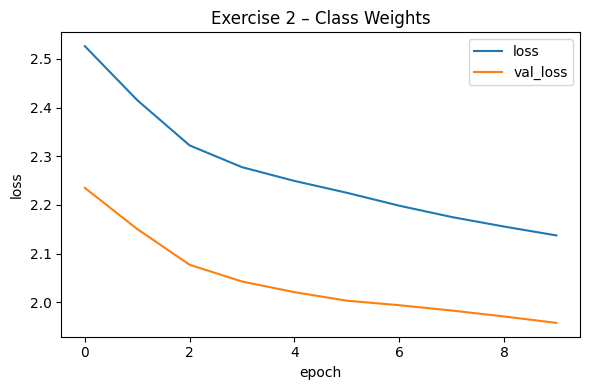

In [9]:
# To-Do: class weights
## ✅ 2.3.1 Class Weights
unique, counts = np.unique(y_imb, return_counts=True)
cw = dict(zip(unique, np.max(counts) / counts))
print("Class weights:", cw)

base_cw = tf.keras.models.clone_model(base)
base_cw.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

h_cw = base_cw.fit(
    x_imb, y_imb,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    class_weight=cw,
    verbose=2
)

plot_history(h_cw, title="Exercise 2 – Class Weights")


Epoch 1/10
42/42 - 19s - 447ms/step - accuracy: 0.1353 - loss: 2.2545
Epoch 2/10
42/42 - 0s - 464us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


42/42 - 8s - 184ms/step - accuracy: 0.1983 - loss: 2.1169
Epoch 4/10
42/42 - 0s - 181us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/10
42/42 - 13s - 301ms/step - accuracy: 0.2289 - loss: 2.0535
Epoch 6/10
42/42 - 0s - 198us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 7/10
42/42 - 7s - 175ms/step - accuracy: 0.2517 - loss: 2.0038
Epoch 8/10
42/42 - 0s - 136us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 9/10
42/42 - 7s - 172ms/step - accuracy: 0.2817 - loss: 1.9697
Epoch 10/10
42/42 - 0s - 139us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00


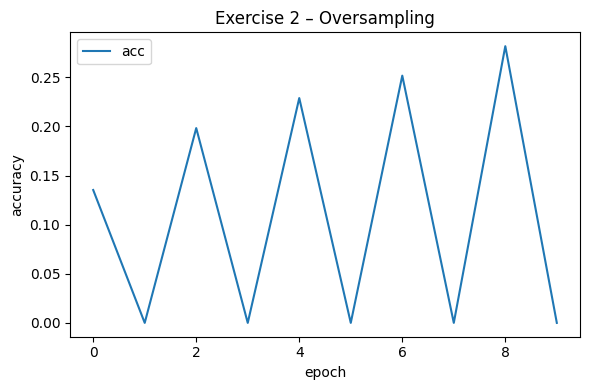

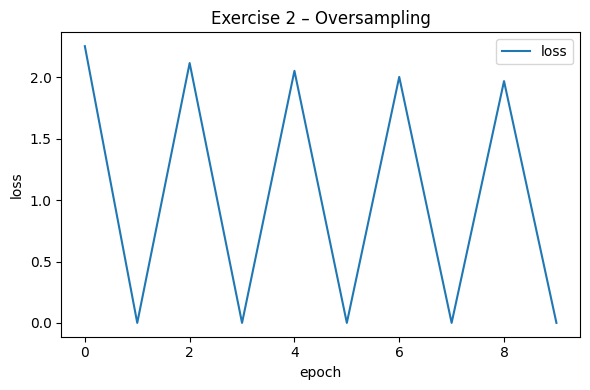

In [10]:
# To-Do: oversampling with tf.data
# # ✅ 2.3.2 Oversampling with tf.data
batch = 128
AUTOTUNE = tf.data.AUTOTUNE

minor_idx = np.where(y_imb == minor_class)[0]
major_idx = np.where(y_imb != minor_class)[0]

ds_minor = tf.data.Dataset.from_tensor_slices((x_imb[minor_idx], y_imb[minor_idx]))
ds_major = tf.data.Dataset.from_tensor_slices((x_imb[major_idx], y_imb[major_idx]))

# Balance sampling
ds_balanced = tf.data.Dataset.sample_from_datasets(
    [ds_minor, ds_major], weights=[0.5, 0.5]
)
ds_balanced = ds_balanced.shuffle(5000).batch(batch).prefetch(AUTOTUNE)

base_os = tf.keras.models.clone_model(base)
base_os.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

h_os = base_os.fit(
    ds_balanced,
    epochs=10,
    steps_per_epoch=math.ceil(len(x_imb)/batch),
    verbose=2
)

plot_history(h_os, title="Exercise 2 – Oversampling")


Epoch 1/10
34/34 - 11s - 323ms/step - accuracy: 0.1200 - loss: 0.4612 - val_accuracy: 0.1170 - val_loss: 0.4540
Epoch 2/10
34/34 - 6s - 181ms/step - accuracy: 0.1564 - loss: 0.4441 - val_accuracy: 0.1858 - val_loss: 0.4291
Epoch 3/10
34/34 - 9s - 267ms/step - accuracy: 0.2045 - loss: 0.4143 - val_accuracy: 0.2434 - val_loss: 0.4012
Epoch 4/10
34/34 - 7s - 191ms/step - accuracy: 0.2318 - loss: 0.3942 - val_accuracy: 0.2632 - val_loss: 0.3879
Epoch 5/10
34/34 - 9s - 278ms/step - accuracy: 0.2491 - loss: 0.3835 - val_accuracy: 0.2840 - val_loss: 0.3813
Epoch 6/10
34/34 - 6s - 181ms/step - accuracy: 0.2696 - loss: 0.3754 - val_accuracy: 0.2934 - val_loss: 0.3754
Epoch 7/10
34/34 - 11s - 311ms/step - accuracy: 0.2847 - loss: 0.3688 - val_accuracy: 0.3019 - val_loss: 0.3708
Epoch 8/10
34/34 - 5s - 156ms/step - accuracy: 0.2981 - loss: 0.3625 - val_accuracy: 0.3160 - val_loss: 0.3665
Epoch 9/10
34/34 - 6s - 183ms/step - accuracy: 0.2986 - loss: 0.3569 - val_accuracy: 0.3189 - val_loss: 0.3626

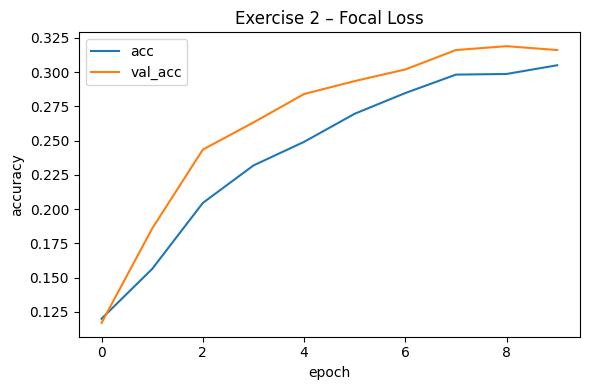

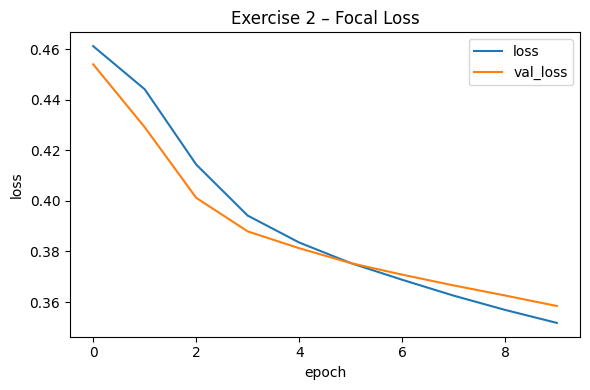

In [11]:
# To-Do: focal loss
# ✅ 2.3.3 Focal Loss
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=10)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))
    return loss_fn

base_fl = tf.keras.models.clone_model(base)
base_fl.compile(optimizer='adam',
                loss=focal_loss(gamma=2.0, alpha=0.25),
                metrics=['accuracy'])

h_fl = base_fl.fit(
    x_imb, y_imb,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

plot_history(h_fl, title="Exercise 2 – Focal Loss")


**Learning point**  
Accuracy hides minority performance. Macro or weighted F1, per class recall, and ROC AUC reveal improvements from imbalance handling.


# Exercise 3: Transfer learning and fine tuning

**As stated in the exercises**  
Use a pre trained backbone such as ResNet, EfficientNet, or Inception. Compare fine tuning strategies to training from scratch. Study the effect of learning rate on fine tuning.


### 3.1 Frozen backbone

**PREFILLED**  
MobileNetV2 is used for speed. The base is frozen. The head is trained first.


In [ ]:
# PREFILLED: just execute
#IMG_FE = (160,160)
#base = tf.keras.applications.MobileNetV2(input_shape=(IMG_FE[0], IMG_FE[1], 3),
 #                                        include_top=False, weights="imagenet")
#base.trainable = False
#preproc = tf.keras.applications.mobilenet_v2.preprocess_input

#def build_head(num_classes=10):
#    inputs = layers.Input(shape=(32,32,3))
#    x = tf.image.resize(inputs, IMG_FE)
#    x = preproc(x)
#    x = base(x, training=False)
#    x = layers.GlobalAveragePooling2D()(x)
#    x = layers.Dense(128, activation="relu")(x)
#    outputs = layers.Dense(num_classes, activation="softmax")(x)
#    return models.Model(inputs, outputs)

#from tensorflow.keras.datasets import cifar10
#(x_tr, y_tr), (x_te, y_te) = cifar10.load_data()
#y_tr = y_tr.ravel(); y_te = y_te.ravel()

#model_frozen = build_head(10)
#model_frozen.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
#hist_frozen = model_frozen.fit(x_tr, y_tr, epochs=5, batch_size=128, validation_split=0.2, verbose=2)
#plot_history(hist_frozen, title="Frozen backbone head training")

# ✅ Corrected Exercise 3.1 – Frozen Backbone
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10

# --- Load CIFAR-10 data ---
(x_tr, y_tr), (x_te, y_te) = cifar10.load_data()
y_tr = y_tr.ravel()
y_te = y_te.ravel()

# --- Pre-trained base ---
IMG_FE = (160, 160)
base = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_FE[0], IMG_FE[1], 3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False
preproc = tf.keras.applications.mobilenet_v2.preprocess_input

# --- Build model head ---
def build_head(num_classes=10):
    inputs = layers.Input(shape=(32, 32, 3))
    # ✅ Use Keras layer for resizing instead of tf.image.resize
    x = layers.Resizing(IMG_FE[0], IMG_FE[1])(inputs)
    x = preproc(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# --- Train frozen model ---
model_frozen = build_head(10)
hist_frozen = model_frozen.fit(
    x_tr, y_tr,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

# --- Plot learning curves (if defined earlier) ---
plot_history(hist_frozen, title="Exercise 3 – Frozen Backbone")


Epoch 1/5


### 3.2 Fine tune

**To-Do:** Unfreeze the top N layers of the backbone. Use a lower learning rate. Train for a few more epochs. Compare accuracy to the frozen model and to a scratch model.


In [ ]:
# To-Do: unfreeze and fine tune
# --- Fine-tune the pretrained base ---

# Unfreeze some top layers of the base model
base.trainable = True
for layer in base.layers[:-40]:  # freeze everything except last ~40 layers
    layer.trainable = False

# Rebuild model using same architecture as before
def build_fine_tuned(num_classes=10):
    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.Resizing(IMG_FE[0], IMG_FE[1])(inputs)
    x = preproc(x)
    x = base(x, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),  # smaller LR for fine-tuning
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build & transfer weights from frozen model
model_ft = build_fine_tuned(10)
model_ft.set_weights(model_frozen.get_weights())

# Train fine-tuned model
hist_ft = model_ft.fit(
    x_tr, y_tr,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

plot_history(hist_ft, title="Exercise 3 – Fine-tuned Backbone")


**Learning point**  
Freeze then fine tune is stable and efficient. Use a lower learning rate for the backbone than for the head to avoid destroying pre trained features.


# Exercise 4: Model interpretability

**As stated in the exercises**  
Train a CNN and understand which regions drive predictions. Use Grad CAM and optionally LIME. Visualize attention maps and reason about relevance and bias.


### 4.1 Grad CAM helper

**PREFILLED**  
The function below computes Grad CAM for a given image and class index for models with a final conv layer.


In [ ]:
# PREFILLED: just execute
def grad_cam(model, img, class_index, layer_name=None):
    if layer_name is None:
        # find last conv layer
        for l in reversed(model.layers):
            if isinstance(l, layers.Conv2D):
                layer_name = l.name
                break
    conv_layer = model.get_layer(layer_name)
    grad_model = tf.keras.models.Model([model.inputs], [conv_layer.output, model.output])
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(tf.expand_dims(img, 0))
        loss = preds[:, class_index]
    grads = tape.gradient(loss, conv_out)
    weights = tf.reduce_mean(grads, axis=(0,1,2))
    cam = tf.reduce_sum(tf.multiply(weights, conv_out[0]), axis=-1)
    cam = tf.maximum(cam, 0) / (tf.reduce_max(cam) + 1e-8)
    cam = tf.image.resize(cam[..., None], img.shape[:2])
    return cam.numpy().squeeze()

def overlay_cam(img, cam, alpha=0.4):
    plt.figure(figsize=(4,4))
    plt.imshow(img.astype("uint8"))
    plt.imshow(cam, cmap="jet", alpha=alpha)
    plt.axis("off"); plt.tight_layout(); plt.show()

### 4.2 Run Grad CAM

**To-Do:** Choose a trained model and a few sample images. Generate Grad CAM maps for the predicted class. Inspect whether highlighted regions correspond to the object. Document your findings.


In [ ]:
# ✅ To-Do: pick a model and sample images, then visualize Grad CAM

# pick the fine-tuned model
model = model_ft

# pick one test image
img = x_te[0]
img = tf.image.resize(img, (160,160))
img = tf.expand_dims(img, 0)

# predict
pred = np.argmax(model.predict(img), axis=1)[0]
print(f"Predicted class: {pred}")

# compute Grad CAM using the helper above
cam = grad_cam(model, img, class_index=pred)

# visualize overlay
overlay_cam(img[0], cam)


**Learning point**  
Grad CAM uses gradients of the target class flowing into the final conv layer to produce a heatmap. It helps verify that the network attends to object regions rather than background artifacts.


![image.png](attachment:image.png)

# Exercise 5: Building a robust classification pipeline

**As stated in the exercises**  
Create a complete pipeline for image classification including data loading, augmentation, training, evaluation, and saving. Optionally build a simple interface for predictions. Make the pipeline modular and robust.


### 5.1 Data module

**PREFILLED**  
A reusable loader using `image_dataset_from_directory`. It supports train and validation splits.


In [ ]:
# PREFILLED: just execute
def load_folder_dataset(root, img_size=(160,160), batch=32, val_split=0.2, seed=42):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        root, validation_split=val_split, subset="training", seed=seed,
        image_size=img_size, batch_size=batch, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        root, validation_split=val_split, subset="validation", seed=seed,
        image_size=img_size, batch_size=batch, label_mode="int"
    )
    class_names = train_ds.class_names
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.cache().prefetch(AUTOTUNE)
    val_ds = val_ds.cache().prefetch(AUTOTUNE)
    return train_ds, val_ds, class_names

### 5.2 Model factory

**To-Do:** Implement a model factory that can return a baseline CNN or a MobileNetV2 transfer model based on a string name. Use sensible defaults and allow passing the number of classes.


In [ ]:
# To-Do: implement model factory
## ✅ To-Do: implement model factory
def make_model(kind, num_classes, img_size=(160,160)):
    if kind == "baseline":
        m = tf.keras.Sequential([
            layers.Conv2D(32, (3,3), activation="relu", input_shape=(*img_size, 3)),
            layers.MaxPooling2D(2,2),
            layers.Conv2D(64, (3,3), activation="relu"),
            layers.MaxPooling2D(2,2),
            layers.Flatten(),
            layers.Dense(128, activation="relu"),
            layers.Dense(num_classes, activation="softmax")
        ])
        m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return m

    elif kind == "mobilenetv2":
        base = tf.keras.applications.MobileNetV2(
            input_shape=(*img_size, 3),
            include_top=False,
            weights="imagenet"
        )
        base.trainable = False
        preproc = tf.keras.applications.mobilenet_v2.preprocess_input

        inputs = layers.Input(shape=(*img_size, 3))
        x = preproc(inputs)
        x = base(x, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        outputs = layers.Dense(num_classes, activation="softmax")(x)

        m = tf.keras.Model(inputs, outputs)
        m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return m

    else:
        raise ValueError("Unknown kind")


### 5.3 Training, evaluation, saving

**To-Do:** Train a selected model on a folder dataset. Evaluate on validation data. Save the model and class names to disk and reload them for a test prediction. Add simple error handling for unknown inputs.


In [ ]:
# ✅ Pre-filled: if you want to do an end-to-end run + saving
root = "path/to/your/dataset"

(train_ds, val_ds, class_names) = load_folder_dataset(root)
model = make_model("mobilenetv2", num_classes=len(class_names))

cb = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
]

hist = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=cb)
plot_history(hist, title="Exercise 5 pipeline")

# save model and labels
model.save("saved_models/robust_cnn_savedmodel")
import json
json.dump(class_names, open("saved_models/robust_cnn_classes.json", "w"))

# reload and test on a single image
reloaded_model = tf.keras.models.load_model("saved_models/robust_cnn_savedmodel")
loaded_classes = json.load(open("saved_models/robust_cnn_classes.json"))

img_path = "path/to/test.jpg"
img = tf.keras.utils.load_img(img_path, target_size=(160,160))
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array / 255.0, 0)

pred = reloaded_model.predict(img_array)
print("✅ Predicted:", loaded_classes[int(np.argmax(pred))], "-", float(np.max(pred)))


**Learning point**  
A robust pipeline is modular and testable. Keep data loading, modeling, and evaluation separate. Save models with their label maps. Validate inputs and fail safely.
